In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import silhouette_score
from xgboost import plot_importance
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC


# Load the cleaned dataset
cleaned_file_path = r"C:\Users\thota\OneDrive\Desktop\Semster 1\Data Intensive Computing\PHASE2 PROJECT\qmmm.csv"    # Use the actual path if different
df = pd.read_csv(cleaned_file_path)
# Drop rows with missing target values
df_cleaned = df.dropna(subset=['resultmeanvalue'])

# Feature selection - Excluding target variable and identifiers
X = df.drop(columns=['resultmeanvalue', 'waterbodyidentifier'])  # Assuming 'resultmeanvalue' is the target
y = df['resultmeanvalue'].apply(lambda x: 1 if x > df['resultmeanvalue'].median() else 0)  # Binary classification


# Standardize features for better performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [4]:
X.shape

(13396, 27)

In [5]:
y.shape

(13396,)

In [6]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Accuracy: {accuracy_nb}")
print(f"Naïve Bayes Classification Report:\n{classification_report(y_test, y_pred_nb)}")


Naïve Bayes Accuracy: 0.501948717948718
Naïve Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.03      0.05      2468
           1       0.50      0.99      0.66      2407

    accuracy                           0.50      4875
   macro avg       0.61      0.51      0.36      4875
weighted avg       0.61      0.50      0.35      4875



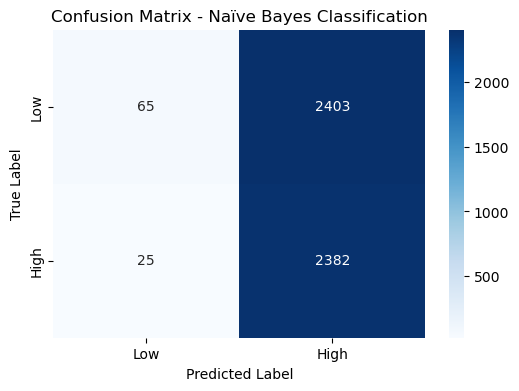

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naïve Bayes Classification")
plt.show()

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")
print(f"KNN Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNN Accuracy: 0.9556923076923077
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      2468
           1       0.92      1.00      0.96      2407

    accuracy                           0.96      4875
   macro avg       0.96      0.96      0.96      4875
weighted avg       0.96      0.96      0.96      4875



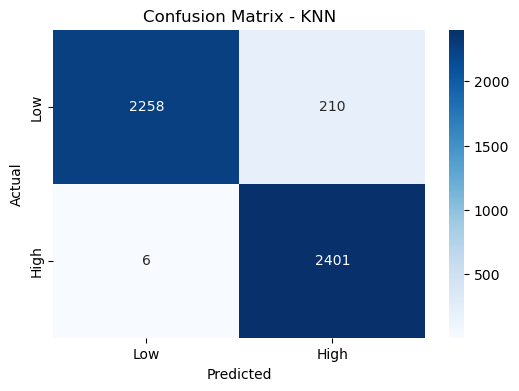

In [10]:
# Confusion Matrix for KNN
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()


In [11]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Evaluate the model
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log}")
print(f"Logistic Regression Classification Report:\n{classification_report(y_test, y_pred_log)}")


Logistic Regression Accuracy: 0.6422564102564102
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.51      0.59      2468
           1       0.61      0.77      0.68      2407

    accuracy                           0.64      4875
   macro avg       0.65      0.64      0.64      4875
weighted avg       0.65      0.64      0.64      4875



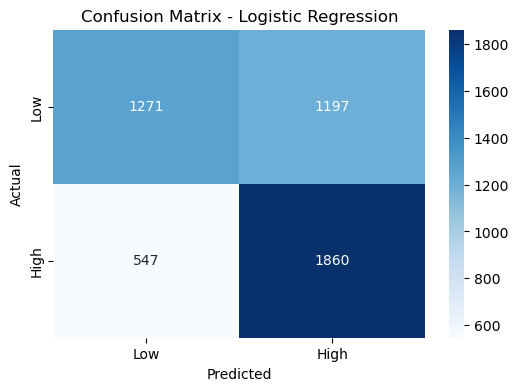

In [12]:


# Confusion Matrix for Logistic Regression
conf_matrix_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Random Forest Accuracy: 0.9561025641025641
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.95      2468
           1       0.92      1.00      0.96      2407

    accuracy                           0.96      4875
   macro avg       0.96      0.96      0.96      4875
weighted avg       0.96      0.96      0.96      4875



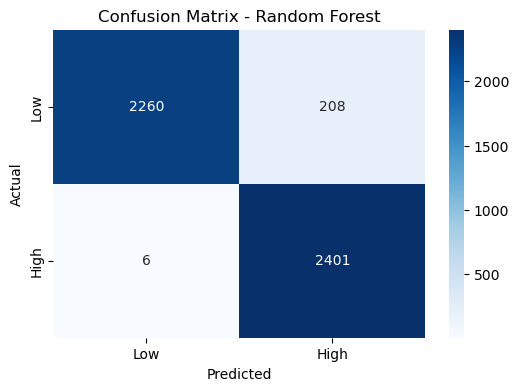

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")
print(f"Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf)}")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


In [14]:
import joblib
joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [12]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
# Train XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the Model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb}")
print(f"XGBoost Classification Report:\n{classification_report(y_test, y_pred_xgb)}")


XGBoost Accuracy: 0.9569230769230769
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2468
           1       0.92      1.00      0.96      2407

    accuracy                           0.96      4875
   macro avg       0.96      0.96      0.96      4875
weighted avg       0.96      0.96      0.96      4875



<Figure size 1000x600 with 0 Axes>

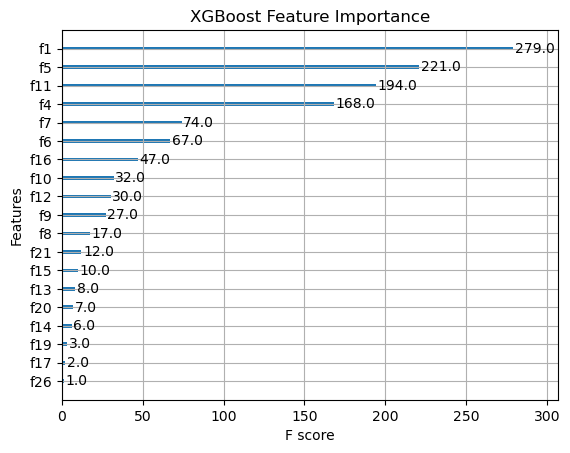

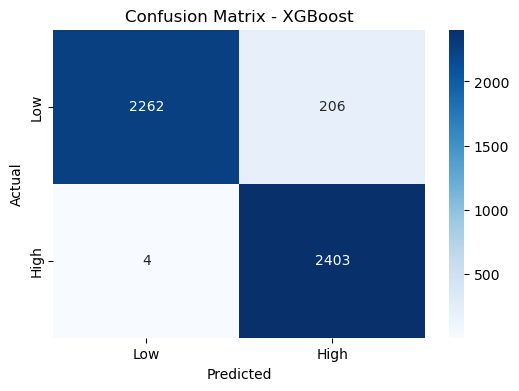

In [13]:
# Train and visualize XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Feature Importance Plot
plt.figure(figsize=(10, 6))
from xgboost import plot_importance
plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()

# Confusion Matrix for XGBoost
y_pred_xgb = xgb_model.predict(X_test)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()


In [ ]:
# Train and evaluate Support Vector Machine
print("Training SVM model...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

# Predictions
print("Making predictions...")
y_pred_svm = svm_model.predict(X_test)
print("Predictions completed.")

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm}")
print(f"SVM Classification Report:\n{classification_report(y_test, y_pred_svm)}")


Training SVM model...


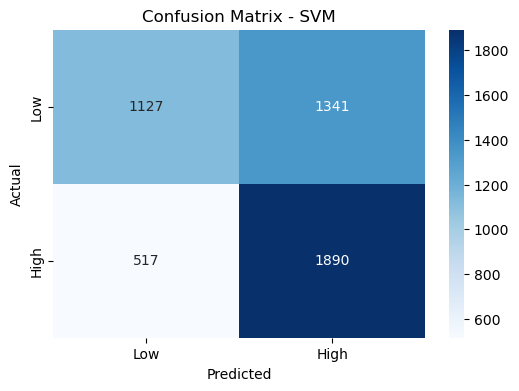

In [ ]:

# Confusion Matrix for SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()
